In [1]:
import fsspec

In [2]:
fsspec.config.conf["s3"] = {
"default_cache_type": "blockcache",
"default_block_size": 2**22
}

In [3]:
import earthaccess
import xarray as xr

In [4]:
tspan = ("2024-08", '2024-08')
results = earthaccess.search_data(short_name="PACE_OCI_L3M_SFREFL", granule_name="*.MO.*.0p1deg.*", temporal=tspan)

In [5]:
paths = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
dataset = xr.open_dataset(paths[0])

In [7]:
dataset

<xarray.Dataset> Size: 3GB
Dimensions:     (lat: 1800, lon: 3600, wavelength: 122, rgb: 3,
                 eightbitcolor: 256)
Coordinates:
  * wavelength  (wavelength) float64 976B 346.0 351.0 ... 2.131e+03 2.258e+03
  * lat         (lat) float32 7kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * lon         (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    rhos        (lat, lon, wavelength) float32 3GB ...
    palette     (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/62)
    product_name:                      PACE_OCI.20240801_20240831.L3m.MO.SFRE...
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    cdm_data_type:                     grid
    identifier_product_doi_authority:  http://dx.doi.org
    identifier_product_doi:            10.5067/PACE/OCI/L3M/SFREFL/3.0
    data_bins:                         5215534
    data_minimum:                      -0.05000001
    data_maximum:                      1.0

In [8]:
rgb = dataset["rhos"].sel({"wavelength": [645, 555, 440]}, method="nearest")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05000001..1.0].


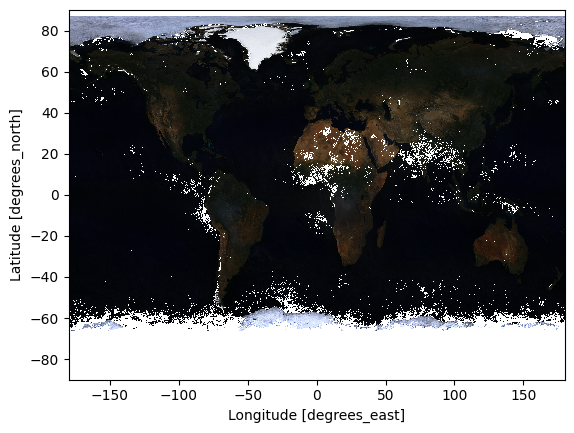

In [9]:
plot = rgb.plot.imshow()

In [10]:
import numpy as np
from PIL import Image, ImageEnhance

rgb
scale = 0.01
vmin = 0
vmax = 1.1
gamma = 1
contrast = 1.1
brightness = 1
sharpness = 1.1
saturation = 1

da = rgb.where(rgb > 0)
da = np.log(da / scale) / np.log(1 / scale)
da = da.clip(vmin, vmax)
da = (da - da.min()) / (da.max() - da.min())
da = da * gamma
da = da * 255
da = da.where(da.notnull(), 0).astype("uint8")
img = Image.fromarray(da.data)
enhancer = ImageEnhance.Contrast(img)
img = enhancer.enhance(contrast)
enhancer = ImageEnhance.Brightness(img)
img = enhancer.enhance(brightness)
enhancer = ImageEnhance.Sharpness(img)
img = enhancer.enhance(sharpness)
enhancer = ImageEnhance.Color(img)
img = enhancer.enhance(saturation)
rgb[:] = np.array(img) / 255

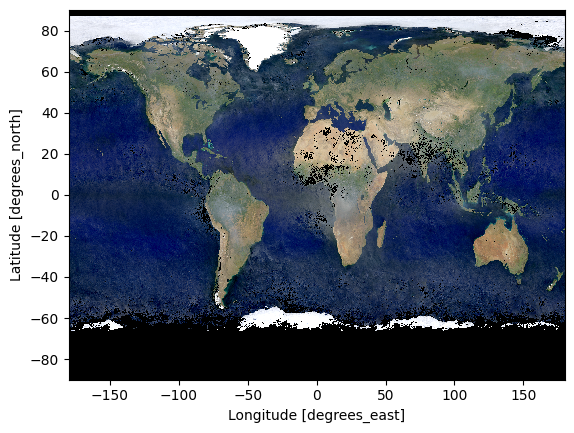

In [11]:
plot = rgb.plot.imshow()